# T5 Sweep Results
Loads all `checkpoints/transformer/t5/*/best.pt` and visualises performance across sweep axes.

Primary metric: **val cosine similarity** on T5 PCA targets. Secondary: 2-AFC, top-k retrieval.

In [8]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR

SWEEP_AXES = ['n_layers', 'd_model', 'nce_weight', 'uniformity_weight']

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted((CHECKPOINT_DIR / 'transformer' / 't5').glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_t5' in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

SORT_BY = 'val_cos_t5'
show_cols = SWEEP_AXES + ['train_cos_t5', 'train_2afc_t5', 'val_cos_t5', 'val_2afc_t5', 'epoch']
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded  |  test metrics present: {has_test}')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))

Loading:   0%|          | 0/27 [00:00<?, ?it/s]

27 runs loaded  |  test metrics present: True
 n_layers  d_model  nce_weight  uniformity_weight  train_cos_t5  train_2afc_t5  val_cos_t5  val_2afc_t5  epoch
        2      256         0.5                0.1      0.832306            1.0    0.092062     0.663265     78
        1      256         0.5                0.1      0.805867            1.0    0.087383     0.630612     61
        1      128         0.5                0.1      0.803322            1.0    0.083753     0.663673     96
        2      256         0.8                0.1      0.675894            1.0    0.082356     0.662041     41
        2      128         0.5                0.1      0.787692            1.0    0.080236     0.641633     96
        1      256         0.5                0.0      0.846409            1.0    0.079923     0.649796     38
        2      256         0.5                0.0      0.899473            1.0    0.079849     0.631020     52
        1      256         0.8                0.1      0.722346   

## Metrics by sweep axis

/tmp/ipykernel_4809/2021885714.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  uw_cmap  = plt.cm.get_cmap('Set1', max(len(uw_vals), 2))


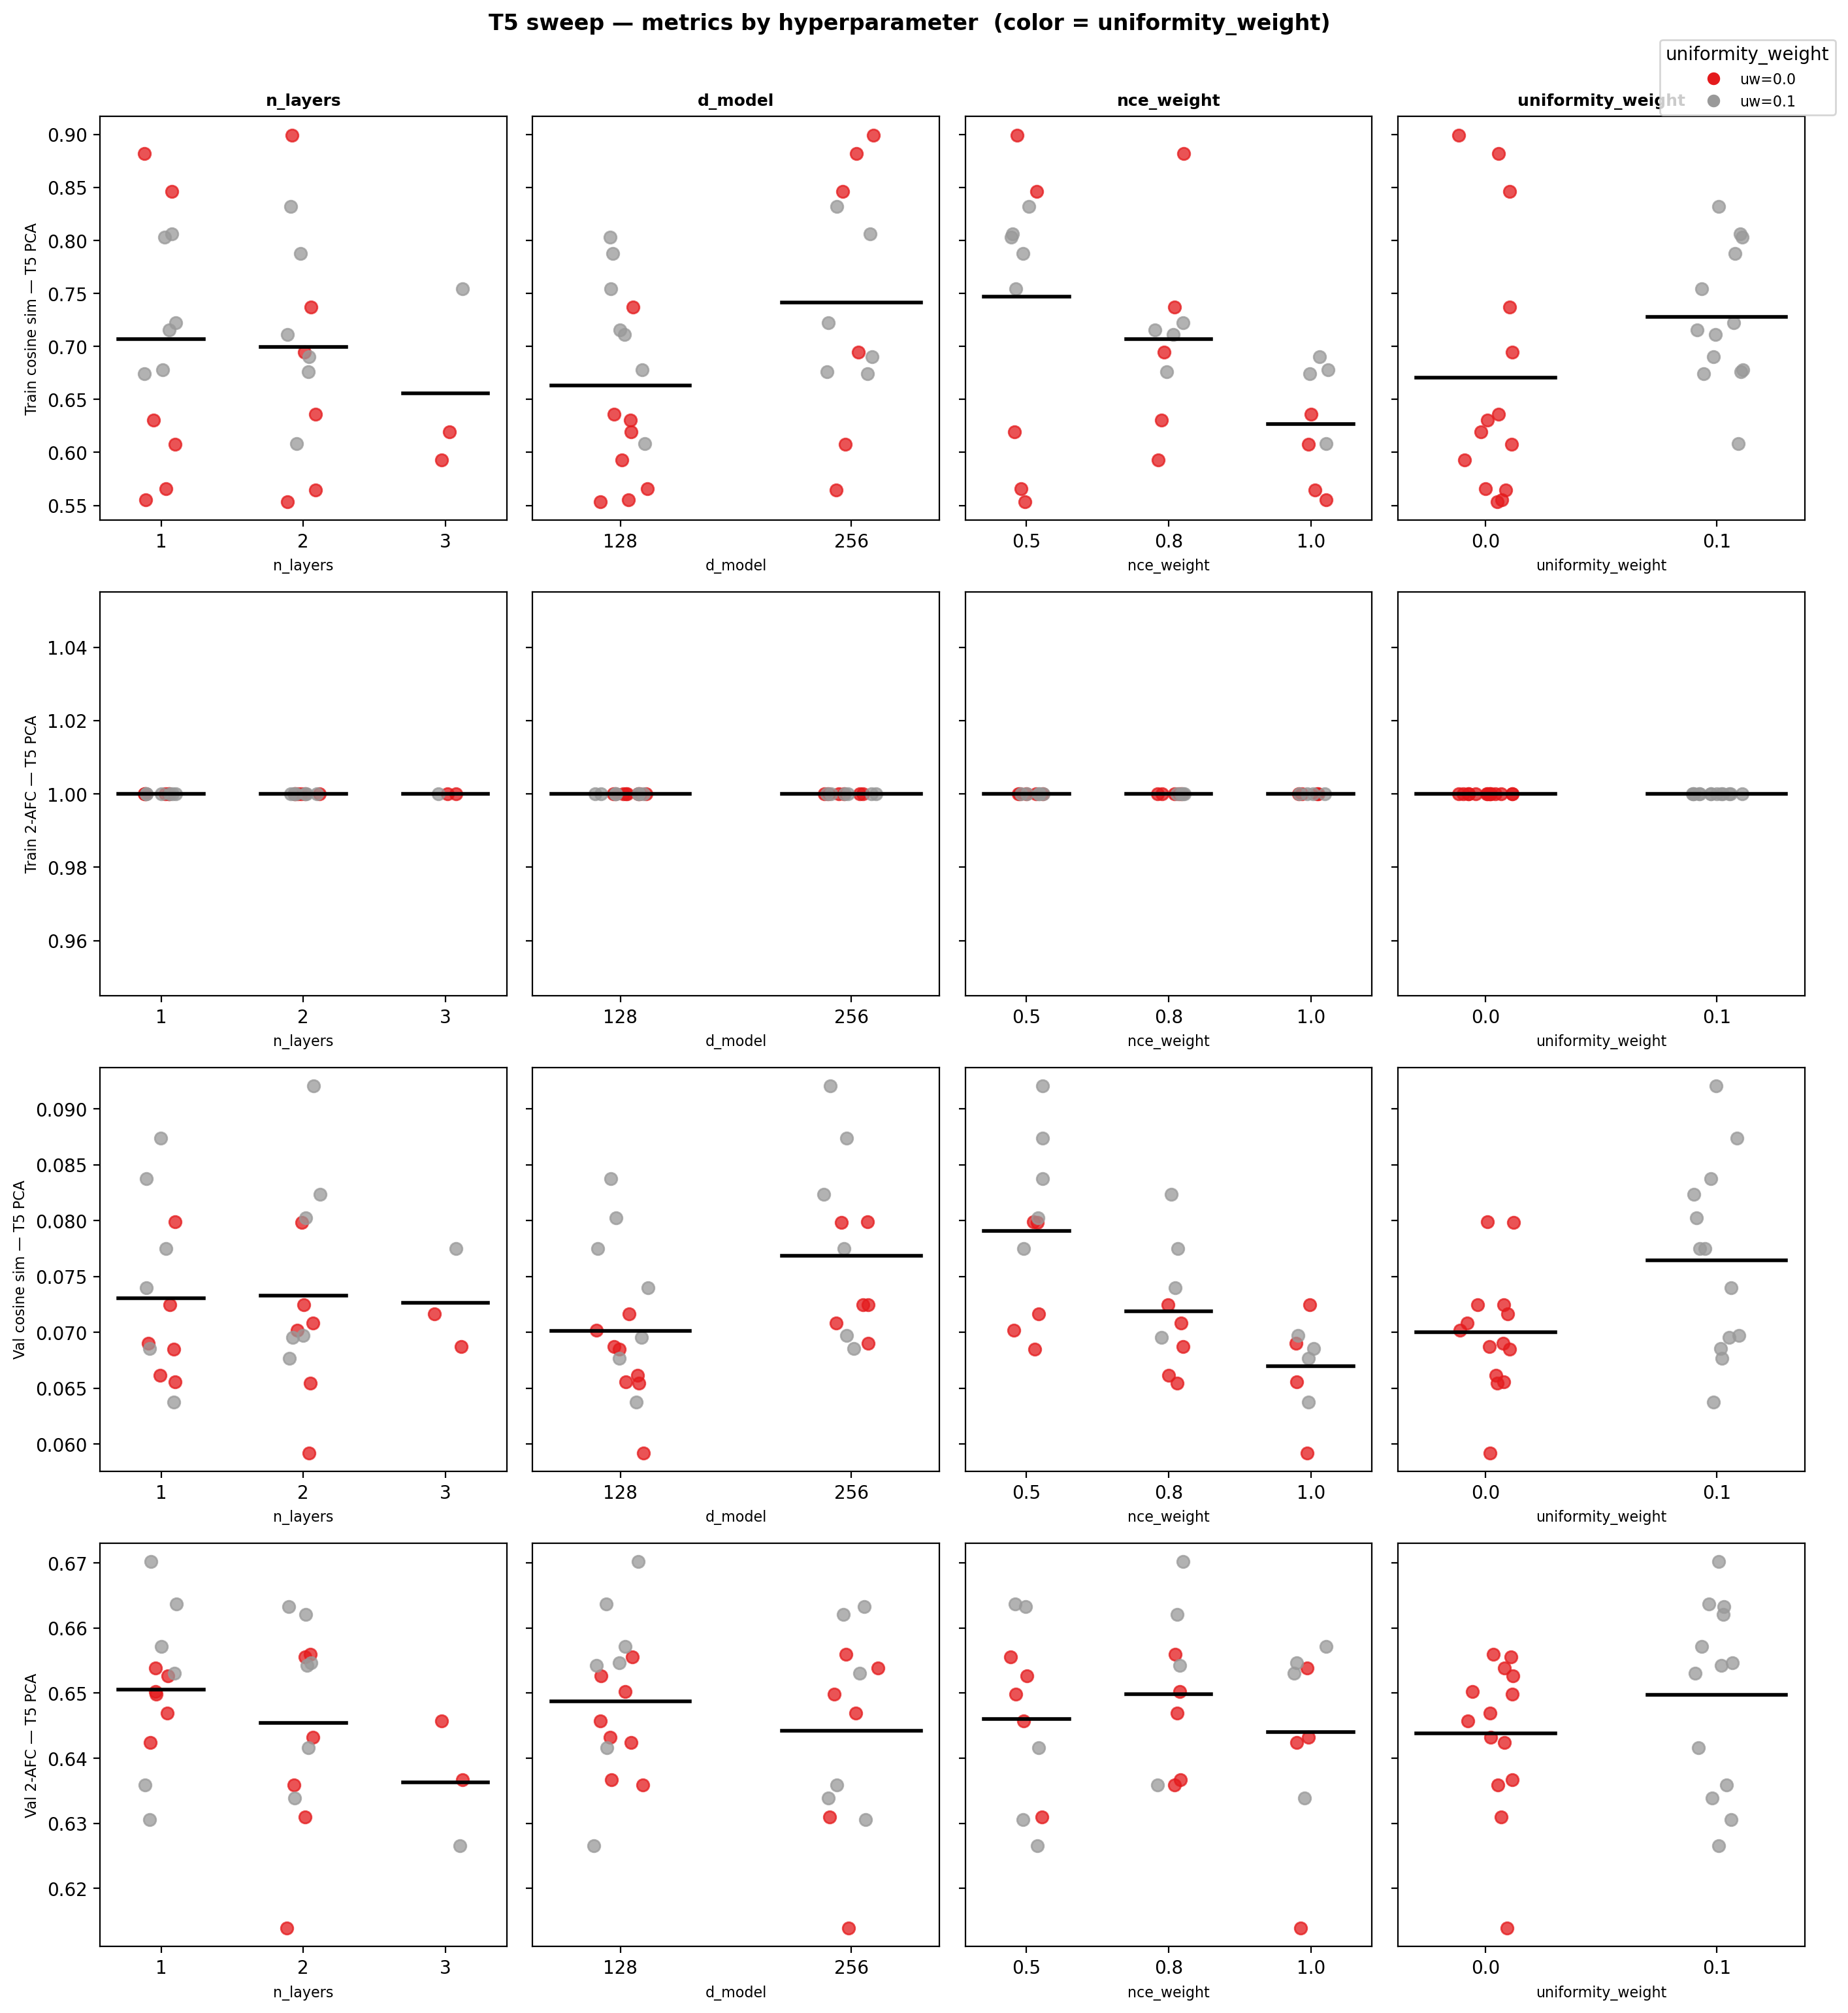

In [9]:
METRICS = [
    ('train_cos_t5',  'Train cosine sim — T5 PCA'),
    ('train_2afc_t5', 'Train 2-AFC — T5 PCA'),
    ('val_cos_t5',    'Val cosine sim — T5 PCA'),
    ('val_2afc_t5',   'Val 2-AFC — T5 PCA'),
]

present_metrics = [(m, l) for m, l in METRICS if m in df.columns]

fig, axes = plt.subplots(len(present_metrics), len(SWEEP_AXES),
                         figsize=(3.5 * len(SWEEP_AXES), 3.8 * len(present_metrics)),
                         sharey='row', squeeze=False)

rng = np.random.default_rng(0)

uw_vals  = sorted(df['uniformity_weight'].unique())
uw_cmap  = plt.cm.get_cmap('Set1', max(len(uw_vals), 2))
uw_color = {v: uw_cmap(i) for i, v in enumerate(uw_vals)}

for mi, (metric, ylabel) in enumerate(present_metrics):
    for ai, axis_col in enumerate(SWEEP_AXES):
        ax = axes[mi, ai]
        if axis_col not in df.columns:
            ax.axis('off'); continue
        levels = sorted(df[axis_col].unique())
        for lvl_i, lvl in enumerate(levels):
            sub = df[df[axis_col] == lvl]
            for uw, grp in sub.groupby('uniformity_weight'):
                vals = grp[metric].dropna().values
                if not len(vals): continue
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=uw_color[uw], alpha=0.75, s=45,
                           label=f'uw={uw}' if ai == 0 and lvl_i == 0 else '_')
            all_vals = sub[metric].dropna().values
            if len(all_vals):
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [all_vals.mean(), all_vals.mean()], 'k-', lw=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])
        ax.set_xlabel(axis_col, fontsize=8)
        if ai == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if mi == 0:
            ax.set_title(axis_col, fontsize=9, fontweight='bold')

handles = [plt.Line2D([0],[0],marker='o',color='w',
           markerfacecolor=uw_color[v],markersize=8,label=f'uw={v}') for v in uw_vals]
fig.legend(handles=handles, title='uniformity_weight', loc='upper right',
           bbox_to_anchor=(1.01, 1), fontsize=8)
fig.suptitle('T5 sweep — metrics by hyperparameter  (color = uniformity_weight)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Effect of nce_weight

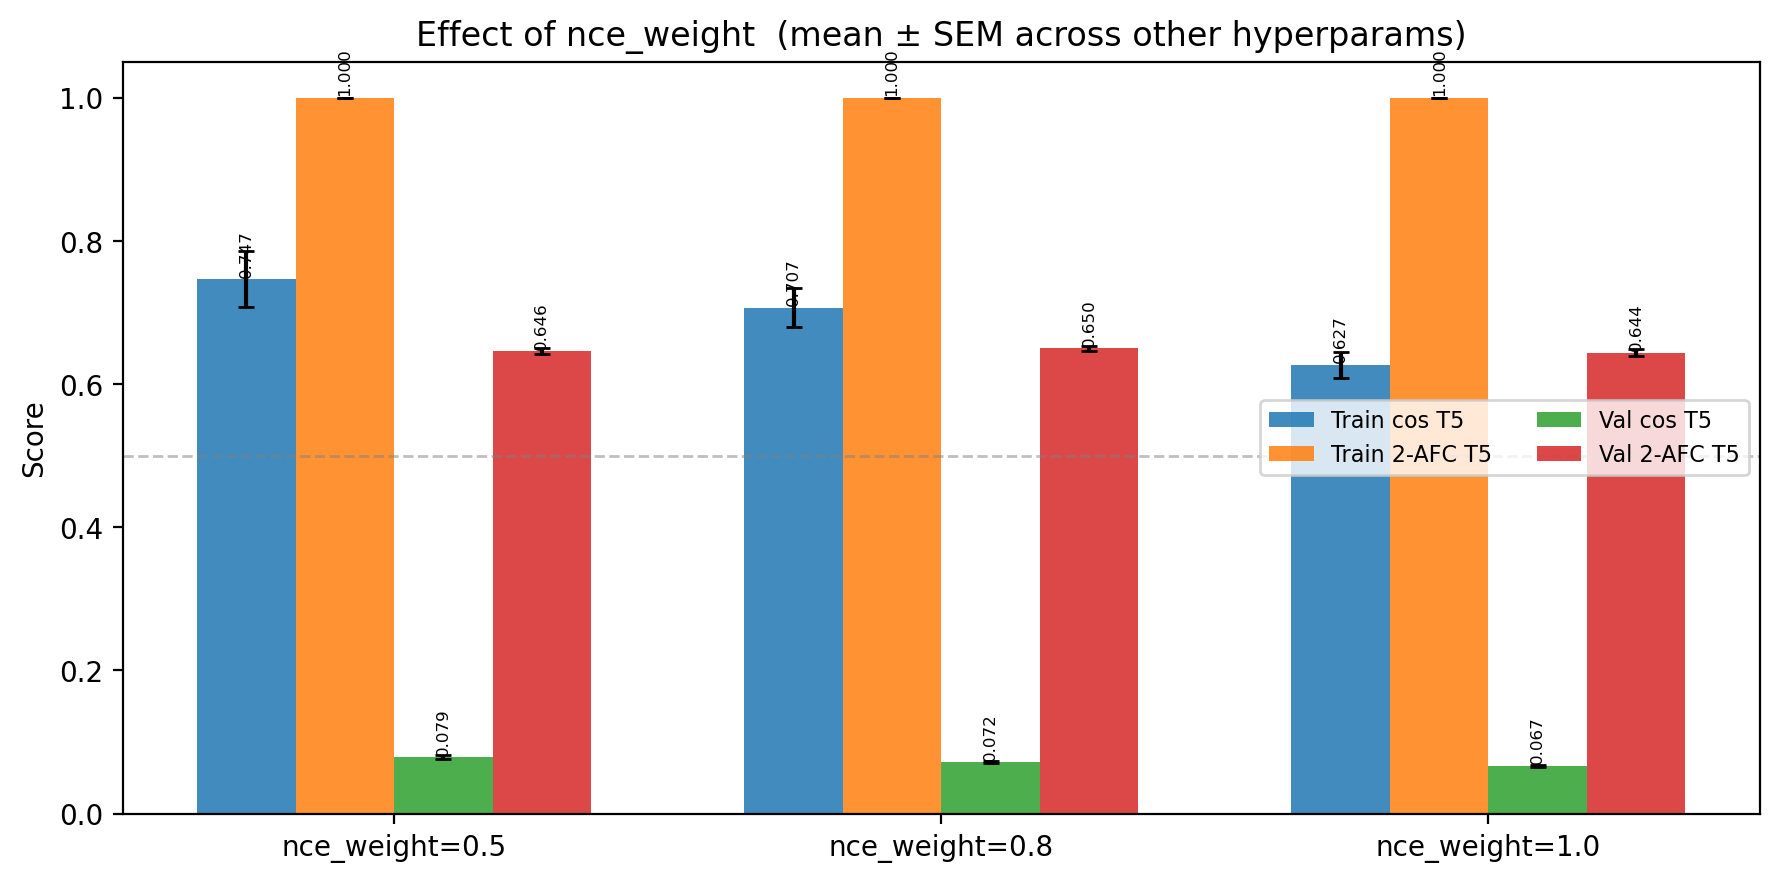

In [10]:
metrics_ab = [
    ('train_cos_t5',  'Train cos T5'),
    ('train_2afc_t5', 'Train 2-AFC T5'),
    ('val_cos_t5',    'Val cos T5'),
    ('val_2afc_t5',   'Val 2-AFC T5'),
]
metrics_ab = [(m, l) for m, l in metrics_ab if m in df.columns]
nw_labels = sorted(df['nce_weight'].unique())
x = np.arange(len(nw_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df['nce_weight'] == w][metric].mean() for w in nw_labels]
    sems  = [df[df['nce_weight'] == w][metric].sem()  for w in nw_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'nce_weight={v}' for v in nw_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of nce_weight  (mean ± SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Train vs val generalisation

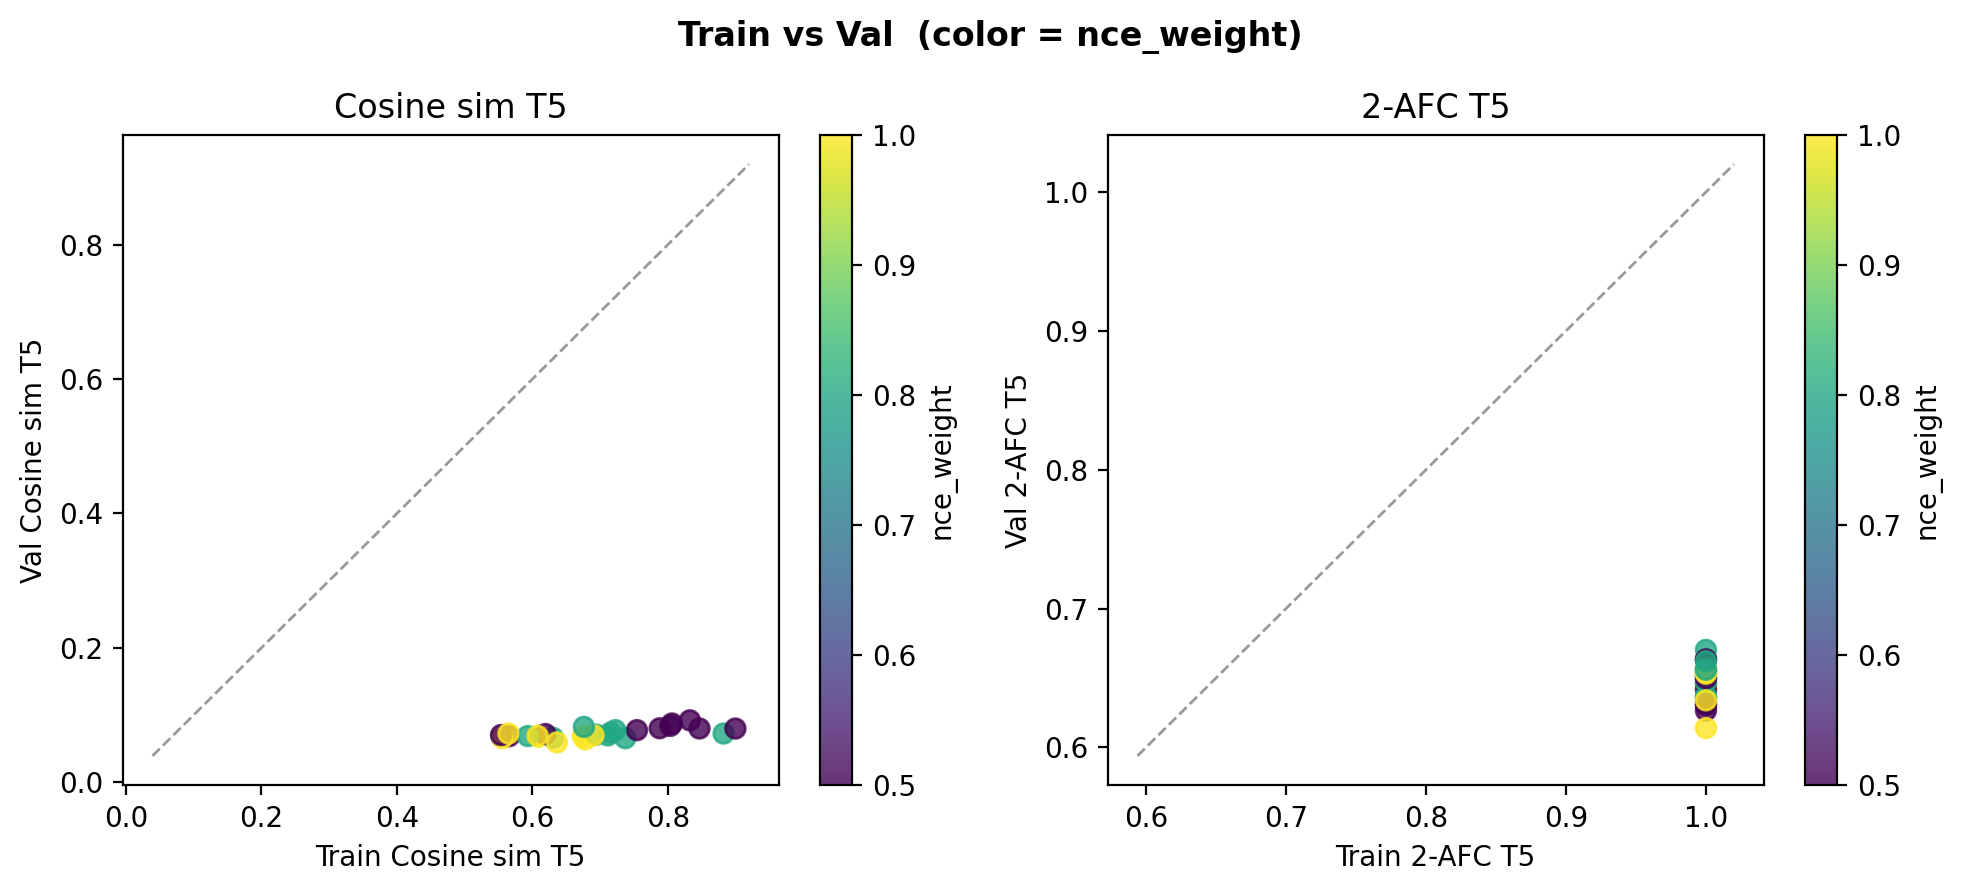

In [11]:
tv_pairs = [
    ('train_cos_t5',  'val_cos_t5',  'Cosine sim T5'),
    ('train_2afc_t5', 'val_2afc_t5', '2-AFC T5'),
]
tv_pairs = [(tc, vc, t) for tc, vc, t in tv_pairs if tc in df.columns and vc in df.columns]

if tv_pairs:
    fig, axes = plt.subplots(1, len(tv_pairs), figsize=(5 * len(tv_pairs), 4.5))
    if len(tv_pairs) == 1:
        axes = [axes]
    for ax, (tcol, vcol, title) in zip(axes, tv_pairs):
        sub = df.dropna(subset=[tcol, vcol])
        sc = ax.scatter(sub[tcol], sub[vcol],
                        c=sub['nce_weight'], cmap='viridis', s=50, alpha=0.8)
        lim = [min(sub[tcol].min(), sub[vcol].min()) - 0.02,
               max(sub[tcol].max(), sub[vcol].max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Train {title}')
        ax.set_ylabel(f'Val {title}')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='nce_weight')
    fig.suptitle('Train vs Val  (color = nce_weight)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Train metrics not yet available — rerun once jobs complete.')

## Val vs test generalisation

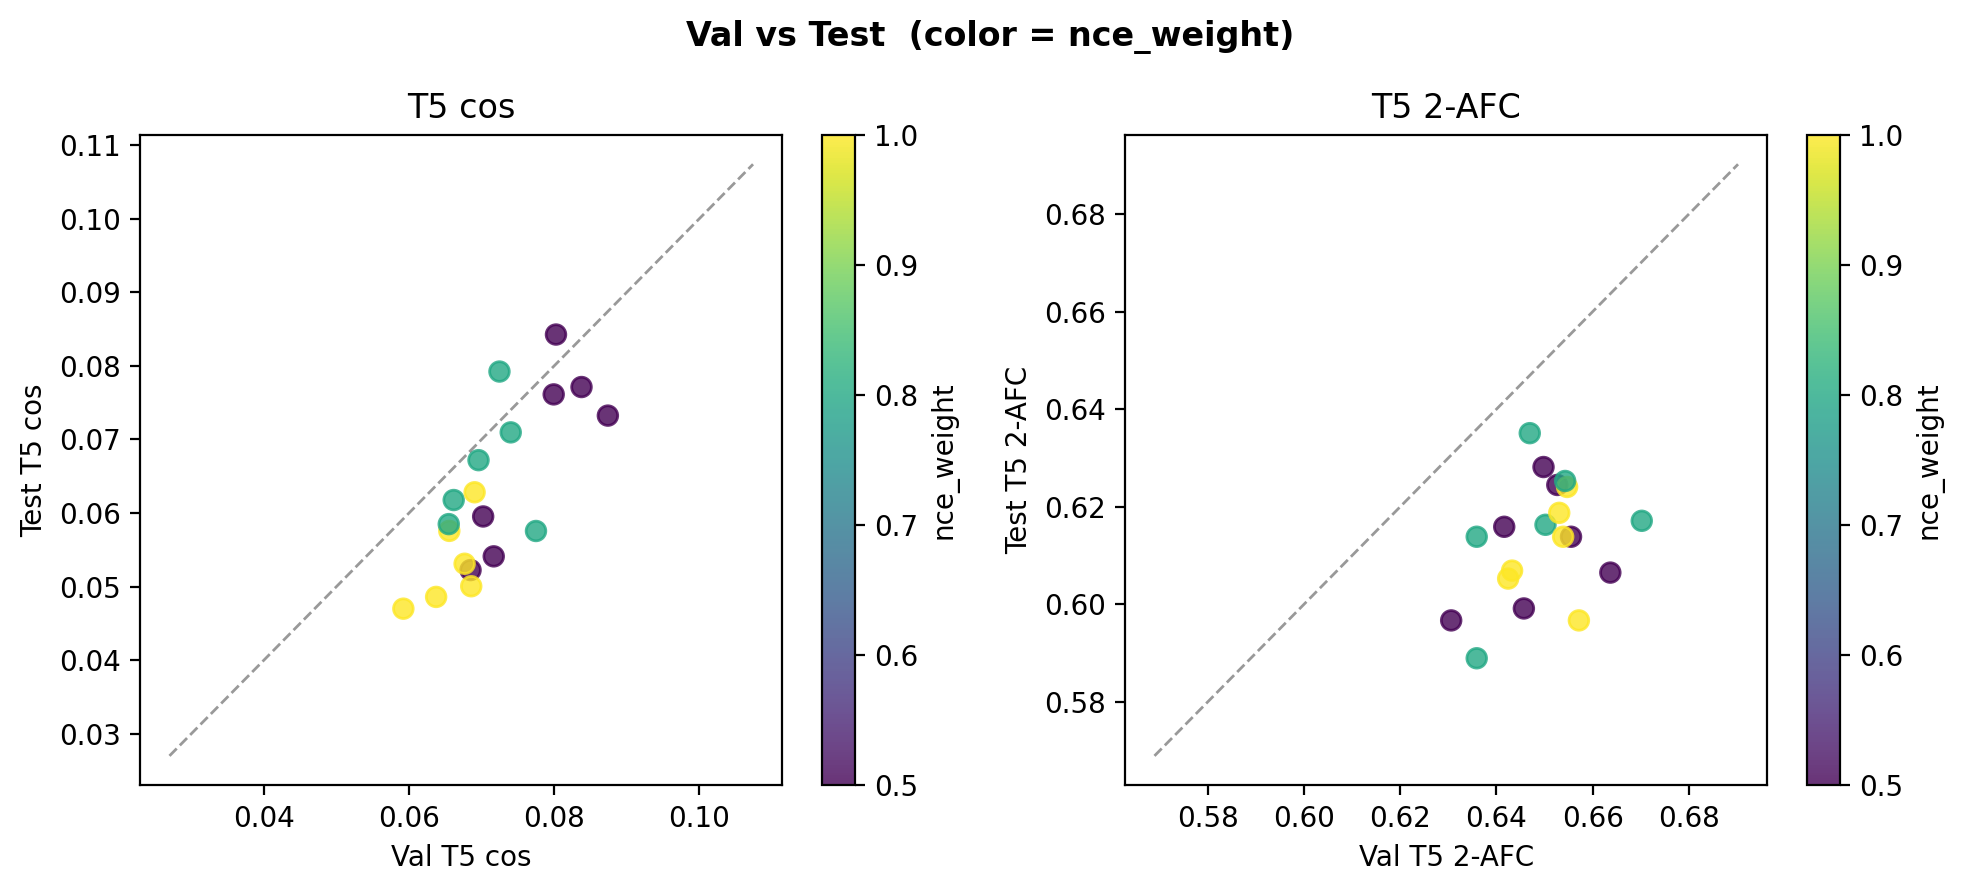

In [12]:
if has_test:
    pairs = [
        ('val_cos_t5',  'test_cos_t5',  'T5 cos'),
        ('val_2afc_t5', 'test_2afc_t5', 'T5 2-AFC'),
    ]
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub = df.dropna(subset=[vcol, tcol])
        sc = ax.scatter(sub[vcol], sub[tcol],
                        c=sub['nce_weight'], cmap='viridis', s=50, alpha=0.8)
        lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
               max(sub[vcol].max(), sub[tcol].max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Val {title}')
        ax.set_ylabel(f'Test {title}')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='nce_weight')
    fig.suptitle('Val vs Test  (color = nce_weight)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available — rerun once all jobs complete.')

## Top-10 runs

In [13]:
top_cols = [c for c in
    ['n_layers', 'd_model', 'nce_weight', 'uniformity_weight',
     'epoch', 'train_cos_t5', 'train_2afc_t5', 'val_cos_t5', 'val_2afc_t5',
     'test_cos_t5', 'test_2afc_t5', 'test_top1', 'test_top5', 'test_top10', 'path']
    if c in df.columns]
display(df.sort_values('val_cos_t5', ascending=False)[top_cols].head(10).reset_index(drop=True))

,n_layers,d_model,nce_weight,uniformity_weight,epoch,train_cos_t5,train_2afc_t5,val_cos_t5,val_2afc_t5,test_cos_t5,test_2afc_t5,test_top1,test_top5,test_top10,path
0,2,256,0.5,0.1,78,0.832306,1.0,0.092062,0.663265,NaN,NaN,NaN,NaN,NaN,/home/yy3658/NeurObjectGen/checkpoints/transfo...
1,1,256,0.5,0.1,61,0.805867,1.0,0.087383,0.630612,0.073227,0.596735,0.06,0.20,0.32,/home/yy3658/NeurObjectGen/checkpoints/transfo...
2,1,128,0.5,0.1,96,0.803322,1.0,0.083753,0.663673,0.077110,0.606531,0.04,0.28,0.38,/home/yy3658/NeurObjectGen/checkpoints/transfo...
3,2,256,0.8,0.1,41,0.675894,1.0,0.082356,0.662041,NaN,NaN,NaN,NaN,NaN,/home/yy3658/NeurObjectGen/checkpoints/transfo...
4,2,128,0.5,0.1,96,0.787692,1.0,0.080236,0.641633,0.084243,0.615918,0.06,0.18,0.36,/home/yy3658/NeurObjectGen/checkpoints/transfo...
5,1,256,0.5,0.0,38,0.846409,1.0,0.079923,0.649796,0.076110,0.628163,0.04,0.22,0.40,/home/yy3658/NeurObjectGen/checkpoints/transfo...
6,2,256,0.5,0.0,52,0.899473,1.0,0.079849,0.631020,NaN,NaN,NaN,NaN,NaN,/home/yy3658/NeurObjectGen/checkpoints/transfo...
7,1,256,0.8,0.1,61,0.722346,1.0,0.077482,0.635918,0.057549,0.588980,0.04,0.16,0.32,/home/yy3658/NeurObjectGen/checkpoints/transfo...
8,3,128,0.5,0.1,81,0.754187,1.0,0.077481,0.626531,NaN,NaN,NaN,NaN,NaN,/home/yy3658/NeurObjectGen/checkpoints/transfo...
9,1,128,0.8,0.1,96,0.715240,1.0,0.074003,0.670204,0.070949,0.617143,0.02,0.22,0.36,/home/yy3658/NeurObjectGen/checkpoints/transfo...


## Save best T5 config

In [14]:
import json
from config_const import CACHE_DIR

best_row = df.sort_values('val_cos_t5', ascending=False).iloc[0]
config = {
    'model': 'transformer_t5',
    'val_cos_t5':   float(best_row['val_cos_t5']),
    'val_2afc_t5':  float(best_row['val_2afc_t5'])  if 'val_2afc_t5'  in best_row else None,
    'train_cos_t5': float(best_row['train_cos_t5']) if 'train_cos_t5' in best_row else None,
    'checkpoint':   best_row['path'],
    'd_model':      int(best_row['d_model']),
    'n_heads':      int(best_row['n_heads']),
    'n_layers':     int(best_row['n_layers']),
    't5_pca_k':     int(best_row['t5_pca_k']),
    'dropout':      float(best_row['dropout']),
    'nce_weight':        float(best_row['nce_weight']),
    'nce_temperature':   float(best_row['nce_temperature']),
    'uniformity_weight': float(best_row['uniformity_weight']),
    'lr':           float(best_row['lr']),
    'weight_decay': float(best_row['weight_decay']),
}

out_path = CACHE_DIR / 'best_t5_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {out_path}')
print(f"  val_cos_t5={config['val_cos_t5']:.4f}")
if config['val_2afc_t5']:
    print(f"  val_2afc_t5={config['val_2afc_t5']:.3f}")
if config['train_cos_t5']:
    print(f"  train_cos_t5={config['train_cos_t5']:.4f}")
print(f"  {config['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_t5_config.json
  val_cos_t5=0.0921
  val_2afc_t5=0.663
  train_cos_t5=0.8323
  /home/yy3658/NeurObjectGen/checkpoints/transformer/t5/d256_nh4_nl2_k128_do0.1_lr0.0003_wd0.01_tn0.0_bs64_nw0.5_nt0.07_uw0.1/best.pt
